# Multiple Linear Regression

scikit-learn offers several datasets you can use to explore and practice machine learning on. We will use the [California Housing Dataset](https://scikit-learn.org/stable/datasets/real_world.html#california-housing-dataset).

### Objectives
1. Explore the data
    - What is the dimensionality of the dataset?
    - What are the features?
    - What are the targets?

2. Visualize the data
    - The dimensionality of this data is larger than 2. How can we visualize this?

3. Train-Test Split
    - Choose the fraction of data in the training, testing and validation sets.

5. Model this data with a multiple linear regression model.
    - For simple linear regression we have $y = m x + b$.
    - For multiple linear regression we have:
    
$$y = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \beta_3 x_3 + ...$$

Where $\beta_i$ is one of the model parameters (like m or b), and $x_i$ is one of the features in the dataset.

4. Objective function
    - Choose the type of objective function, L1 or L2, and write it as a function.

5. Use [an optimizer](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.minimize.html#scipy.optimize.minimize) to find the optimal set of parameters ($\beta_i$) for the model.

6. Calculate the performance on the training and testing sets.
    - Write a function that calculates the $R^2$.

7. Use [LinearRegression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html) from sklearn to fit the same model.

8. Compare the fitted parameters from the two algorithms we used to fit the model.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import optimize
from matplotlib import pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split

In [2]:
housing = fetch_california_housing()

In [3]:
type(housing)

sklearn.utils._bunch.Bunch

In [4]:
dir(housing)

['DESCR', 'data', 'feature_names', 'frame', 'target', 'target_names']

In [5]:
print(housing.DESCR)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

In [6]:
housing.data.shape

(20640, 8)

In [7]:
housing.feature_names

['MedInc',
 'HouseAge',
 'AveRooms',
 'AveBedrms',
 'Population',
 'AveOccup',
 'Latitude',
 'Longitude']

In [8]:
housing.frame

In [9]:
housing.target.shape

(20640,)

In [10]:
housing.target_names

['MedHouseVal']

In [11]:
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25
...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32


In [12]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
dtypes: float64(8)
memory usage: 1.3 MB


In [20]:
df[columns]

,MedInc,HouseAge,AveRooms,Population
0,8.3252,41.0,6.984127,322.0
1,8.3014,21.0,6.238137,2401.0
2,7.2574,52.0,8.288136,496.0
3,5.6431,52.0,5.817352,558.0
4,3.8462,52.0,6.281853,565.0
...,...,...,...,...
20635,1.5603,25.0,5.045455,845.0
20636,2.5568,18.0,6.114035,356.0
20637,1.7000,17.0,5.205543,1007.0
20638,1.8672,18.0,5.329513,741.0


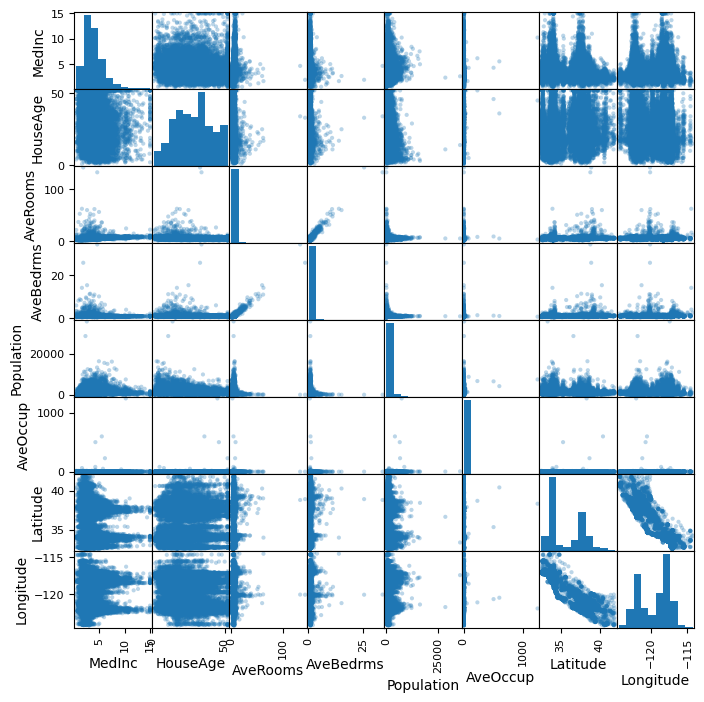

In [51]:
# columns = ["MedInc", "HouseAge", "AveRooms", "Population"]
pd.plotting.scatter_matrix(df, alpha=0.3, figsize=(8, 8));

In [15]:
Xtrn, X_tv, Ytrn, Y_tv = train_test_split(housing.data, housing.target, train_size=12_000, random_state=1415)

Xtst, Xval, Ytst, Yval = train_test_split(X_tv, Y_tv, train_size=0.50, random_state=1415)

In [16]:
Xtrn.shape, Xval.shape, Xtst.shape

((12000, 8), (4320, 8), (4320, 8))

In [17]:
Ytrn.shape, Yval.shape, Ytst.shape

((12000,), (4320,), (4320,))

In [40]:
def linear_model(x, beta):
    y = beta[0]  # Intercept term
    y += beta[1] * x[:, 0]  # The MedInc term
    y += beta[2] * x[:, 1]  # The HouseAge term
    y += beta[3] * x[:, 2]  # The AveRooms term
    y += beta[4] * x[:, 3]  # The AveBedrms term
    y += beta[5] * x[:, 4]  # The Population term
    y += beta[6] * x[:, 5]  # The AveOccup term
    y += beta[7] * x[:, 6]  # The Latitude term
    y += beta[8] * x[:, 7]  # The Longitude term
    return y


def objective(beta, x=Xtrn, y_true=Ytrn):
    y_pred = linear_model(x, beta)
    SSE = np.sum((y_true - y_pred)**2)
    return SSE

In [41]:
housing.data.shape

(20640, 8)

In [42]:
beta0 = [1, 1, 1, 1, 1, 1, 1, 1, 1]
res = optimize.minimize(objective, beta0, method="SLSQP")

In [43]:
res

     message: Optimization terminated successfully
     success: True
      status: 0
         fun: 6101.768293361041
           x: [-3.707e+01  4.270e-01  1.010e-02 -9.851e-02  6.509e-01
                1.660e-05 -1.050e-01 -4.342e-01 -4.414e-01]
         nit: 20
         jac: [ 4.407e-02  2.183e-01  9.819e-01  2.192e-01  4.065e-02
                1.140e+02  1.535e-01  1.613e+00 -5.382e+00]
        nfev: 250
        njev: 20
 multipliers: []

In [44]:
res.x

array([-3.70718491e+01,  4.27023558e-01,  1.01040354e-02, -9.85145128e-02,
        6.50939868e-01,  1.65976240e-05, -1.05033493e-01, -4.34243400e-01,
       -4.41405271e-01])

In [47]:
def get_r_squared(beta, x, y_true):
    y_pred = linear_model(x, beta)
    RSS = np.sum((y_true - y_pred)**2)
    TSS = np.sum((y_true - np.mean(y_true))**2)
    r_squared = 1 - RSS / TSS
    return r_squared

get_r_squared(res.x, Xtrn, Ytrn)

np.float64(0.6166158347137449)

In [48]:
get_r_squared(res.x, Xval, Yval)

np.float64(-2.8038534908074175)

In [49]:
objective(res.x, Xtrn, Ytrn)

np.float64(6101.768293361041)

In [50]:
objective(res.x, Xval, Yval)

np.float64(21548.089483619086)

In [52]:
get_r_squared(res.x, Xtst, Ytst)

np.float64(-0.011795888020814216)

In [53]:
linreg = LinearRegression()
linreg.fit(Xtrn, Ytrn)

LinearRegression()

In [54]:
linreg.coef_

array([ 4.27077618e-01,  1.01092362e-02, -9.85644923e-02,  6.51106974e-01,
        1.66311476e-05, -1.05037732e-01, -4.34002641e-01, -4.41139919e-01])

In [55]:
linreg.intercept_

np.float64(-37.04900709388816)

In [56]:
res.x

array([-3.70718491e+01,  4.27023558e-01,  1.01040354e-02, -9.85145128e-02,
        6.50939868e-01,  1.65976240e-05, -1.05033493e-01, -4.34243400e-01,
       -4.41405271e-01])

In [57]:
linreg.score(Xtrn, Ytrn)

0.6166158590573192

In [58]:
linreg.score(Xval, Yval)

-2.8040994751457364

In [59]:
linreg.score(Xtst, Ytst)

-0.01182211514442244